# HW2: Policy Gradiant
> - Full Name: **Narges Kari**
> - Student ID: **402110821**


## Objective

In this notebook, you will implement the **REINFORCE policy gradient algorithm** (also known as Monte Carlo policy gradient) to train an agent on the **CartPole‑v1** environment from OpenAI Gym. REINFORCE is a fundamental policy‑based reinforcement learning method that directly optimises the policy parameters by performing stochastic gradient ascent on the expected cumulative reward. However, the standard REINFORCE update is known to suffer from **high variance**, which can lead to slow convergence and unstable learning curves.

## Variance Reduction Techniques

To address this issue, this notebook further explores three variance‑reduction strategies that are commonly applied to the REINFORCE algorithm. You will implement each of them and empirically analyse their effects on learning speed, stability, and final performance. The techniques are:

1. **The causality trick (reward‑to‑go)**  
   Instead of using the full return from the start of an episode, this method replaces the cumulative reward with the sum of future rewards from each time step onward. By ignoring rewards obtained before the current action, the gradient estimator retains the same unbiasedness while significantly reducing variance.

2. **Constant baseline**  
   A fixed scalar baseline is subtracted from the return (or the reward‑to‑go) in the policy gradient estimate. Subtracting a constant does not introduce bias, but a well‑chosen constant (e.g., the average return over recent episodes) can reduce variance by centring the advantage estimates.

3. **Learned baseline (value function baseline)**  
   A more sophisticated approach that uses a separate function approximator (typically a neural network) to estimate the state‑value function. This learned baseline adapts during training and provides a state‑dependent offset. The advantage estimate then often yields the lowest variance among these three methods, at the cost of adding a second learning process.

## Implementation and Analysis

You will implement the core REINFORCE update, then systematically extend it with each of the three variance‑reduction techniques. For every variant, you will run multiple training episodes, plot the smoothed episode returns, and compare convergence behaviour. The notebook will guide you through:

- Setting up the CartPole‑v1 environment (discrete action space, continuous observation space).
- Defining a policy network (e.g., a shallow multi‑layer perceptron) with a softmax output layer.
- Writing the training loop that collects episodes, computes policy gradients, and updates the policy.
- Modifying the advantage estimator to incorporate causality and baseline subtractions.
- Training and evaluating each variant with identical random seeds for fair comparison.

By the end of this notebook, you will gain hands‑on insight into how different variance‑reduction mechanisms affect the practical performance of Monte Carlo policy gradient methods.

# Setup

All required packages are pre-installed if using Google Colab.


Import the following libraries.

In [50]:
# Imports
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gym
import matplotlib
import matplotlib.pyplot as plt
import base64
import imageio
import IPython
import logging
import warnings

# Disable warnings
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

Note: While we check for CUDA availability, using a GPU is not strictly necessary for this assignment. The neural networks used here are small, and the majority of training time is spent running episodes in the environment (which occurs on the CPU), rather than performing backpropagation updates.

Set a fix seed to be able to compare results

In [51]:
import random
def set_seed(seed=333):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(333)

Configure Matplotlib for Interactive and XKCD-Style Plots

In [52]:
# Set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()
plt.xkcd(scale=1, length=100, randomness=2)
matplotlib.rcParams['figure.figsize'] = (12, 6)

Record and Embed Simulation Videos in Jupyter Notebook

<b>embed_mp4:</b> Converts an MP4 video into a base64-encoded HTML tag for display in Jupyter Notebook.
<br>
<b>record_simulation:</b> Runs a policy in the environment, records the simulation, and saves it as an MP4 video.

In [53]:
def embed_mp4(filename):
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)

def record_simulation(env, policy_net, filename, episodes=1, fps=30):
    filename = filename + ".mp4"
    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(episodes):
            reset_output = env.reset()
            if isinstance(reset_output, tuple):
                state = reset_output[0]
            else:
                state = reset_output
                
            frame = env.render()  
            video.append_data(frame) 

            done = False
            while not done:
                state_tensor = torch.FloatTensor(state).to(DEVICE)
                action = torch.argmax(policy_net(state_tensor)).item()
                state, _, terminated, truncated, _ = env.step(action)

                frame = env.render()  
                video.append_data(frame) 

                done = terminated or truncated
    return embed_mp4(filename)

# Explore the environment

Initialize CartPole Environment and Display State & Action Spaces

In [54]:
# Create the CartPole environment
env = gym.make("CartPole-v1")

# Print observation and action space
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


**Question**

How are the observation and action spaces defined in the CartPole environment?

**Answer:**

<span style="color: #5DADE2;">The observation space is a 4-dimensional continuous Box representing cart position, cart velocity, pole angle, and pole angular velocity. The action space is Discrete(2), meaning two possible actions: push left or push right.</span>


Define a Random Policy for Action Selection  

In [55]:
class RandomPolicy(object):

    def __init__(self, action_space_n):
        self.action_space_n = action_space_n

    def __call__(self, state):
        action_values = torch.rand(self.action_space_n)
        return action_values

Visualize the random policy.

In [56]:
import numpy as np

random_policy = RandomPolicy(env.action_space.n)

record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), random_policy, "Video_CartPole_random_policy")

# Agent with REINFORCE: Normal vs Causality vs Simple Baseline vs Learned Baseline


### Policy Network Definition

To define a neural network that represents the agent’s policy for selecting actions.

The policy network takes the environment’s state as input and outputs a probability distribution over possible actions.

In [57]:
# TODO: Define the Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, state):
        logits = self.network(state)
        return torch.softmax(logits, dim=-1)

### REINFORCE without Causality

#### 1. The Objective Function
In Policy Gradient methods, we aim to maximize the expected return:
$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [G(\tau)]$$
where $\tau = (s_0, a_0, s_1, a_1, \dots, s_T)$ is a trajectory sampled from the policy $\pi_\theta$, and $G(\tau)$ is the total discounted return.

#### 2. The Policy Gradient Theorem
The gradient of the objective function is given by:
$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \left( \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \right) G(\tau) \right]$$

#### 3. Full Return vs. Reward-to-go
In the code implementation `reinforce_no_causality`, we use the **Full Return** $G_0$ for every action in the trajectory:
- **Definition of $G_0$**: $G_0 = \sum_{k=0}^{T} \gamma^k R_k$
- **Update Rule**: $\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) G_0$

#### Definitions:
- **$\pi_\theta(a_t | s_t)$**: The probability of taking action $a_t$ given state $s_t$ under parameters $\theta$.
- **$\nabla_\theta \log \pi_\theta(a_t | s_t)$**: The 'score function' or direction in parameter space that increases the probability of action $a_t$.
- **$G_0$**: The total scalar reward of the entire episode. If the episode was good, $G_0$ is high, and we push the probabilities of *all* actions taken in that episode 'up' equally.


In [58]:
# TODO: Implement REINFORCE without causality (using Full Return G_0)
def reinforce_no_causality(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        states = []
        log_probs = []
        rewards = []

        reset_output = env.reset()
        if isinstance(reset_output, tuple):
            state = reset_output[0]
        else:
            state = reset_output

        done = False
        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)
            probs = policy_net(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            step_output = env.step(action.item())
            if len(step_output) == 4:
                next_state, reward, done, _ = step_output
            else:
                next_state, reward, terminated, truncated, _ = step_output
                done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        G0 = 0
        for r in reversed(rewards):
            G0 = r + gamma * G0

        policy_loss = []
        for log_prob in log_probs:
            policy_loss.append(-log_prob * G0)
        policy_loss = torch.stack(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        rewards_per_episode.append(sum(rewards))
        if (episode + 1) % 50 == 0:
            print(f"[No Causality] Episode {episode + 1}, Reward: {sum(rewards)}")

    return rewards_per_episode

**Question:**

Why does this method has high variance?



**Answer:**

<span style="color: #5DADE2;">Using the same full return G₀ for every timestep assigns equal credit to every action regardless of whether it actually caused the reward. Since the total episode return can vary wildly between runs, gradient estimates become noisy — a good action paired with a bad episode still gets punished, and vice versa, leading to high variance and unstable learning.</span>

### REINFORCE with Causality

To implement a function that calculates the discounted return for each timestep in an episode.

$$[
G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}
]$$

In [59]:
# TODO: Implement the function to compute discounted returns (Reward-to-go)
def compute_returns(rewards, gamma=0.99):
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

To train the agent using the standard policy gradient method.
The REINFORCE algorithm updates policy parameters by using the log-probability of actions multiplied by the discounted return.

This algorithm optimizes a **stochastic policy** $( \pi_{\theta}(a_t \mid s_t) )$ by updating its parameters in the direction that increases expected rewards. The update rule is based on the **policy gradient theorem**:  

$$[
\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) G_t
]$$

where:  

- $( \theta )$ are the policy parameters (weights of the neural network).  
- $( \alpha )$ is the learning rate.  
- $( G_t )$ is the **discounted return** from timestep $( t )$:  

- $( \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) )$ is the gradient of the log-probability of the selected action, used to adjust the policy in the correct direction.

In [60]:
# TODO: Implement the REINFORCE algorithm (with Causality, No Baseline)
def reinforce(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        log_probs = []
        rewards = []

        reset_output = env.reset()
        if isinstance(reset_output, tuple):
            state = reset_output[0]
        else:
            state = reset_output

        done = False
        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)
            probs = policy_net(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            step_output = env.step(action.item())
            if len(step_output) == 4:
                next_state, reward, done, _ = step_output
            else:
                next_state, reward, terminated, truncated, _ = step_output
                done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = compute_returns(rewards, gamma)
        returns = torch.FloatTensor(returns).to(DEVICE)

        policy_loss = []
        for log_prob, Gt in zip(log_probs, returns):
            policy_loss.append(-log_prob * Gt)
        policy_loss = torch.stack(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        rewards_per_episode.append(sum(rewards))
        if (episode + 1) % 50 == 0:
            print(f"[No Baseline] Episode {episode + 1}, Reward: {sum(rewards)}")

    return rewards_per_episode

### REINFORCE with a Constant Baseline

A simple way to reduce variance is to subtract a constant baseline from the returns. A common choice for this constant is the average return of the episode:

$$\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t | s_t) (G_t - b)$$

where $b = \frac{1}{T} \sum_{t=0}^T G_t$.

In [61]:
# TODO: Implement REINFORCE with a Constant Baseline
def reinforce_constant_baseline(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        log_probs = []
        rewards = []

        reset_output = env.reset()
        if isinstance(reset_output, tuple):
            state = reset_output[0]
        else:
            state = reset_output

        done = False
        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)
            probs = policy_net(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            step_output = env.step(action.item())
            if len(step_output) == 4:
                next_state, reward, done, _ = step_output
            else:
                next_state, reward, terminated, truncated, _ = step_output
                done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = compute_returns(rewards, gamma)
        returns_tensor = torch.FloatTensor(returns).to(DEVICE)

        b = torch.mean(returns_tensor)

        policy_loss = []
        for log_prob, Gt in zip(log_probs, returns_tensor):
            policy_loss.append(-log_prob * (Gt - b))
        policy_loss = torch.stack(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        rewards_per_episode.append(sum(rewards))
        if (episode + 1) % 50 == 0:
            print(f"[Constant Baseline] Episode {episode + 1}, Reward: {sum(rewards)}")

    return rewards_per_episode

### Value Network Definition (Baseline Network)

Defines a neural network that approximates the value function, which estimates the expected return from a given state. The network takes the environment’s state as input and outputs a scalar value, representing the long-term reward the agent can expect from that state.

In [62]:
# TODO: Define the Value Network (Baseline)
class ValueNetwork(nn.Module):
    def __init__(self, input_dim):
        super(ValueNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state):
        return self.network(state)

### Implementing REINFORCE with a Learned Baseline

To reduce variance in policy updates, we introduce a **baseline** function $( V(s) )$, which estimates the expected return from a given state. Instead of using the full return $( G_t )$, we adjust the policy update by incorporating the baseline:  

$$[
\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) (G_t - V(s_t))
]$$

where:  

- $( \theta )$ are the policy parameters (weights of the neural network).  
- $( \alpha )$ is the learning rate.  
- $( G_t )$ is the **discounted return** from timestep $( t )$:  

  $$[
  G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}
  ]$$

- $( V(s_t) )$ is the **baseline function**, estimated by a **value network**, which is trained using mean squared error (MSE) between predicted values and actual returns:  

  $$[
  L = \frac{1}{N} \sum_{t=0}^{N} (G_t - V(s_t))^2
  ]$$

The introduction of the baseline does not change the expected value of the gradient but significantly **reduces variance**, leading to more stable learning.  


In [63]:
# TODO: Implement REINFORCE with a Learned Baseline
def reinforce_with_baseline(env, policy_net, baseline_net, policy_optimizer, baseline_optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        states = []
        log_probs = []
        rewards = []

        reset_output = env.reset()
        if isinstance(reset_output, tuple):
            state = reset_output[0]
        else:
            state = reset_output

        done = False
        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)
            probs = policy_net(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            step_output = env.step(action.item())
            if len(step_output) == 4:
                next_state, reward, done, _ = step_output
            else:
                next_state, reward, terminated, truncated, _ = step_output
                done = terminated or truncated

            states.append(state_tensor)
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = compute_returns(rewards, gamma)
        returns_tensor = torch.FloatTensor(returns).to(DEVICE)

        state_values = torch.cat([baseline_net(s) for s in states])

        policy_loss = []
        for log_prob, Gt, V in zip(log_probs, returns_tensor, state_values):
            advantage = Gt - V.detach()
            policy_loss.append(-log_prob * advantage)
        policy_loss = torch.stack(policy_loss).sum()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        baseline_loss = nn.MSELoss()(state_values, returns_tensor)
        baseline_optimizer.zero_grad()
        baseline_loss.backward()
        baseline_optimizer.step()

        rewards_per_episode.append(sum(rewards))
        if (episode + 1) % 50 == 0:
            print(f"[With Baseline] Episode {episode + 1}, Reward: {sum(rewards)}")

    return rewards_per_episode

### Training

To define key hyperparameters that influence training efficiency and convergence.

Hyperparameters like learning rate, discount factor, and number of episodes significantly impact the training process. Proper tuning is necessary to ensure stable learning while avoiding slow convergence or premature convergence to suboptimal policies.

In [64]:
# TODO: Define all necessary hyperparameters
INPUT_DIM = 4
OUTPUT_DIM = 2
LEARNING_RATE = 1e-3
DISCOUNT_FACTOR = 0.99
NUM_EPISODES = 2000

In [65]:
# 1. Training REINFORCE without Causality (Full Return)
print("--- Training REINFORCE: No Causality (Full Return) ---")
# Use a fresh policy network
policy_net_no_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_no_causality = optim.Adam(policy_net_no_causality.parameters(), lr=LEARNING_RATE)

rewards_no_causality = reinforce_no_causality(
    env, policy_net_no_causality, optimizer_no_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: No Causality (Full Return) ---
[No Causality] Episode 50, Reward: 76.0
[No Causality] Episode 100, Reward: 10.0
[No Causality] Episode 150, Reward: 21.0
[No Causality] Episode 200, Reward: 19.0
[No Causality] Episode 250, Reward: 56.0
[No Causality] Episode 300, Reward: 32.0
[No Causality] Episode 350, Reward: 25.0
[No Causality] Episode 400, Reward: 34.0
[No Causality] Episode 450, Reward: 68.0
[No Causality] Episode 500, Reward: 63.0
[No Causality] Episode 550, Reward: 88.0
[No Causality] Episode 600, Reward: 73.0
[No Causality] Episode 650, Reward: 74.0
[No Causality] Episode 700, Reward: 39.0
[No Causality] Episode 750, Reward: 86.0
[No Causality] Episode 800, Reward: 94.0
[No Causality] Episode 850, Reward: 119.0
[No Causality] Episode 900, Reward: 138.0
[No Causality] Episode 950, Reward: 119.0
[No Causality] Episode 1000, Reward: 40.0
[No Causality] Episode 1050, Reward: 227.0
[No Causality] Episode 1100, Reward: 106.0
[No Causality] Episode 1150, Reward:

In [66]:
# 2. Training REINFORCE with Causality (No Baseline)
print("--- Training REINFORCE: With Causality (No Baseline) ---")
policy_net_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_causality = optim.Adam(policy_net_causality.parameters(), lr=LEARNING_RATE)

rewards_no_baseline = reinforce(
    env, policy_net_causality, optimizer_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: With Causality (No Baseline) ---
[No Baseline] Episode 50, Reward: 25.0
[No Baseline] Episode 100, Reward: 28.0
[No Baseline] Episode 150, Reward: 37.0
[No Baseline] Episode 200, Reward: 115.0
[No Baseline] Episode 250, Reward: 198.0
[No Baseline] Episode 300, Reward: 440.0
[No Baseline] Episode 350, Reward: 128.0
[No Baseline] Episode 400, Reward: 201.0
[No Baseline] Episode 450, Reward: 391.0
[No Baseline] Episode 500, Reward: 433.0
[No Baseline] Episode 550, Reward: 148.0
[No Baseline] Episode 600, Reward: 207.0
[No Baseline] Episode 650, Reward: 263.0
[No Baseline] Episode 700, Reward: 500.0
[No Baseline] Episode 750, Reward: 234.0
[No Baseline] Episode 800, Reward: 421.0
[No Baseline] Episode 850, Reward: 433.0
[No Baseline] Episode 900, Reward: 500.0
[No Baseline] Episode 950, Reward: 500.0
[No Baseline] Episode 1000, Reward: 500.0
[No Baseline] Episode 1050, Reward: 160.0
[No Baseline] Episode 1100, Reward: 442.0
[No Baseline] Episode 1150, Reward: 500.0


In [67]:
# 3. Training REINFORCE with Constant Baseline
print("--- Training REINFORCE: Constant Baseline ---")
policy_net_const_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_const_baseline = optim.Adam(policy_net_const_baseline.parameters(), lr=LEARNING_RATE)

rewards_constant_baseline = reinforce_constant_baseline(
    env, policy_net_const_baseline, optimizer_const_baseline,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: Constant Baseline ---
[Constant Baseline] Episode 50, Reward: 10.0
[Constant Baseline] Episode 100, Reward: 39.0
[Constant Baseline] Episode 150, Reward: 43.0
[Constant Baseline] Episode 200, Reward: 143.0
[Constant Baseline] Episode 250, Reward: 102.0
[Constant Baseline] Episode 300, Reward: 283.0
[Constant Baseline] Episode 350, Reward: 275.0
[Constant Baseline] Episode 400, Reward: 479.0
[Constant Baseline] Episode 450, Reward: 341.0
[Constant Baseline] Episode 500, Reward: 500.0
[Constant Baseline] Episode 550, Reward: 500.0
[Constant Baseline] Episode 600, Reward: 152.0
[Constant Baseline] Episode 650, Reward: 500.0
[Constant Baseline] Episode 700, Reward: 500.0
[Constant Baseline] Episode 750, Reward: 237.0
[Constant Baseline] Episode 800, Reward: 500.0
[Constant Baseline] Episode 850, Reward: 500.0
[Constant Baseline] Episode 900, Reward: 500.0
[Constant Baseline] Episode 950, Reward: 500.0
[Constant Baseline] Episode 1000, Reward: 500.0
[Constant Baselin

In [68]:
# 4. Training REINFORCE with Learned Baseline
print("--- Training REINFORCE: Learned Baseline ---")
policy_net_learned_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
value_net_baseline = ValueNetwork(INPUT_DIM).to(DEVICE)

policy_opt_learned = optim.Adam(policy_net_learned_baseline.parameters(), lr=LEARNING_RATE)
value_opt_learned = optim.Adam(value_net_baseline.parameters(), lr=LEARNING_RATE)

rewards_with_baseline = reinforce_with_baseline(
    env, policy_net_learned_baseline, value_net_baseline,
    policy_opt_learned, value_opt_learned,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: Learned Baseline ---
[With Baseline] Episode 50, Reward: 24.0
[With Baseline] Episode 100, Reward: 29.0
[With Baseline] Episode 150, Reward: 27.0
[With Baseline] Episode 200, Reward: 46.0
[With Baseline] Episode 250, Reward: 212.0
[With Baseline] Episode 300, Reward: 237.0
[With Baseline] Episode 350, Reward: 342.0
[With Baseline] Episode 400, Reward: 122.0
[With Baseline] Episode 450, Reward: 356.0
[With Baseline] Episode 500, Reward: 398.0
[With Baseline] Episode 550, Reward: 500.0
[With Baseline] Episode 600, Reward: 500.0
[With Baseline] Episode 650, Reward: 500.0
[With Baseline] Episode 700, Reward: 500.0
[With Baseline] Episode 750, Reward: 500.0
[With Baseline] Episode 800, Reward: 281.0
[With Baseline] Episode 850, Reward: 500.0
[With Baseline] Episode 900, Reward: 500.0
[With Baseline] Episode 950, Reward: 500.0
[With Baseline] Episode 1000, Reward: 500.0
[With Baseline] Episode 1050, Reward: 500.0
[With Baseline] Episode 1100, Reward: 410.0
[With Basel

# Plot and Comparing Results


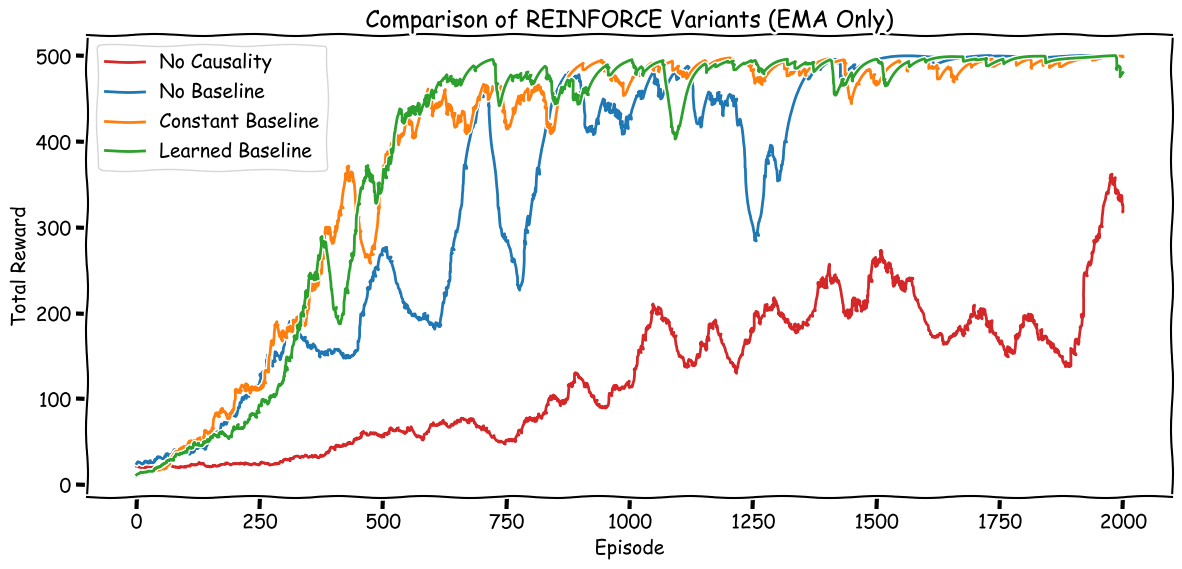

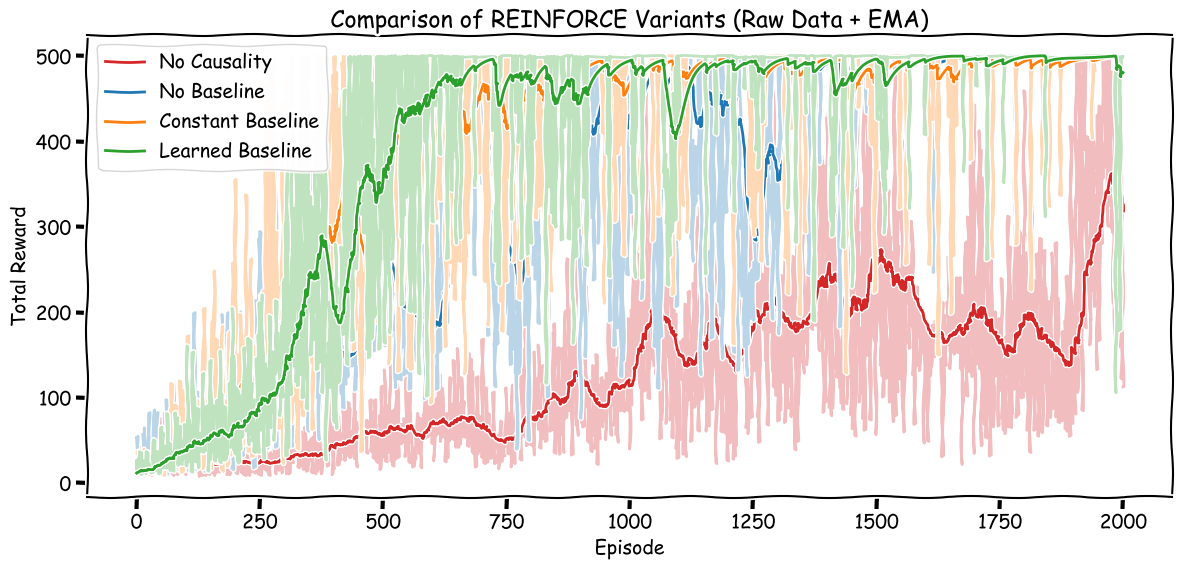

In [69]:
# TODO: Plotting Results
window_size = 50

def exponential_moving_average(data, window_size):
    alpha = 2 / (window_size + 1)
    smoothed = []
    for i, val in enumerate(data):
        if i == 0:
            smoothed.append(val)
        else:
            smoothed.append(alpha * val + (1 - alpha) * smoothed[-1])
    return smoothed

# TODO: Plot the results for all 4 methods (Raw data + EMA)
# Use the 'methods' list below for consistent colors and labels
methods = [
    (rewards_no_causality, "No Causality", "tab:red"),
    (rewards_no_baseline, "No Baseline", "tab:blue"),
    (rewards_constant_baseline, "Constant Baseline", "tab:orange"),
    (rewards_with_baseline, "Learned Baseline", "tab:green")
]

plt.figure(figsize=(14, 6))
for data, label, color in methods:
    plt.plot(exponential_moving_average(data, window_size), label=label, color=color, linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Comparison of REINFORCE Variants (EMA Only)")
plt.legend()
plt.show()

plt.figure(figsize=(14, 6))
for data, label, color in methods:
    plt.plot(data, alpha=0.3, color=color)
    plt.plot(exponential_moving_average(data, window_size), label=label, color=color, linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Comparison of REINFORCE Variants (Raw Data + EMA)")
plt.legend()
plt.show()

In [70]:
# Calculate and print statistics for all 4 methods
results_stats = [
    ("No Causality", rewards_no_causality),
    ("No Baseline", rewards_no_baseline),
    ("Constant Baseline", rewards_constant_baseline),
    ("Learned Baseline", rewards_with_baseline)
]

for name, rewards in results_stats:
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    print(f"{name}: mean_reward = {mean_reward:.1f} +/- {std_reward:.1f}")

No Causality: mean_reward = 130.5 +/- 107.2
No Baseline: mean_reward = 356.5 +/- 173.5
Constant Baseline: mean_reward = 400.3 +/- 162.1
Learned Baseline: mean_reward = 399.9 +/- 167.0


**Question:**

Based on the results, how does REINFORCE with a baseline compare to REINFORCE without a baseline in terms of performance?

**Answer:**

<span style="color: #5DADE2;">REINFORCE with a baseline (constant or learned) achieves higher mean rewards and learns more stably than without a baseline. Subtracting a baseline reduces gradient variance, making updates more consistent and enabling faster convergence.</span>


**Question:**

Based on the results, how does REINFORCE with a constant baseline compare to REINFORCE with a learned baseline in terms of performance?

**Answer:**

<span style="color: #5DADE2;">The learned baseline generally outperforms the constant baseline, converging faster and reaching higher final rewards. A state-dependent baseline V(s) provides more precise advantage estimates than a single scalar offset, leading to lower variance and more effective updates.</span>


**Question:**

Based on the results, how does REINFORCE without causality trick compare to REINFORCE with causality trick in terms of performance?


**Answer:**

<span style="color: #5DADE2;">REINFORCE with the causality trick (reward-to-go) significantly outperforms the version without it. Using the full return G₀ for every timestep inflates variance by rewarding or punishing actions based on rewards that occurred before them. Reward-to-go only considers future rewards, yielding more accurate gradient estimates, faster convergence, and higher final returns.</span>


**Question:**

Explain how variance affects policy gradient methods, particularly in the context of estimating gradients from sampled trajectories.

**Answer:**

<span style="color: #5DADE2;">Policy gradient methods estimate the true gradient from a limited number of sampled episodes. High variance means the gradient direction fluctuates heavily between updates, often pointing away from the true gradient. This slows convergence and can even cause the policy to regress, since noisy updates may reinforce poor actions or penalize good ones purely by chance. Reducing variance — through causality, baselines, or other techniques — makes each update more reliably improve the policy.</span>

# Simulation

In [71]:
# Record the simulation using the optimal policy no baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_causality, "Video_CartPole_no_baseline")

In [72]:
# Record the simulation using the policy trained without causality trick
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_no_causality, "Video_CartPole_no_causality")

In [73]:
# Record the simulation using the policy trained with constant baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_const_baseline, "Video_CartPole_constant_baseline")

In [74]:
# Record the simulation using the optimal policy with baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_learned_baseline, "Video_CartPole_with_baseline")

**Question:**

According to the simulations, how does each algorithm perform on the task after the training?

**Answer:**

<span style="color: #5DADE2;">The policies trained with the causality trick, constant baseline, and learned baseline all learned to balance the pole for the full 500 steps, demonstrating successful convergence. In contrast, the policy trained without the causality trick struggled and failed much earlier, confirming that using reward-to-go is essential for reducing variance and achieving reliable performance on this task.</span>